# Poisonous Mushroom Classification - EDA Report
**Group G · Dataset Version 44**  
**Team:** Mariia Triapitsina · Illia Solovei · Sophia Hmyria

## Problem Statement and Success Criterion

Given a dataset of physical mushroom characteristics, train a **binary classifier** that labels each specimen as edible (`0`) or poisonous (`1`).

**Why the choice of metric matters.** The two error types are not symmetric:
- A *false negative* - predicting *edible* for a mushroom that is actually *poisonous* - kills someone.
- A *false positive* - predicting *poisonous* for a safe mushroom - merely discards it, i.e. wastes a mushroom.

This asymmetry drove three decisions that recur throughout the project:
1. We optimised for **recall on the poisonous class** as the safety-critical number.
2. We report **F1** as the balanced summary metric.
3. We trained every model with **`class_weight="balanced"`** so the minority (poisonous) class was not ignored.

**On F1 scores that appear low.** Our F1 values are pulled down by *precision*, not recall - the models flag more edible mushrooms as poisonous than necessary. For a food-safety classifier, that is the correct direction of error: we accept false alarms in exchange for minimising the risk of calling a poisonous mushroom safe. F1 alone is therefore not the right lens for judging these models.

## The Data at First Contact and First Noticed Complications

The training file `mushroom_v44_train.csv` contains **10,590 rows and 9 columns**. Two immediate red flags shaped the entire project.

### I. Hugely imbalanced distribution

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

=== Class balance ===
  Edible: 8174  (77.2%)
  Poisonous: 2416  (22.8%)
  A model predicting 'edible' for every row scores 77% accuracy - yet is lethal.


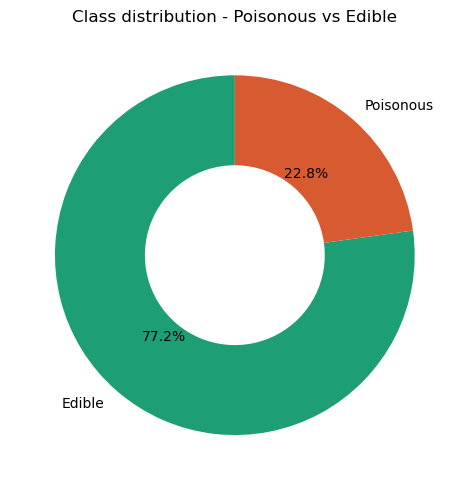

class
0    8174
1    2416
Name: count, dtype: int64


In [15]:
df = pd.read_csv("mushroom_v44_train.csv")

counts = df["class"].value_counts()
print("=== Class balance ===")
for lbl, cnt in counts.items():
    print(f"  {'Poisonous' if lbl else 'Edible'}: {cnt}  ({cnt/len(df)*100:.1f}%)")
print("  A model predicting 'edible' for every row scores 77% accuracy - yet is lethal.")

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['class'].value_counts()
ax.pie(counts, labels=["Edible", "Poisonous"],
       colors=["#1D9E75", "#D85A30"], autopct='%1.1f%%',
       startangle=90, wedgeprops=dict(width=0.5))
ax.set_title('Class distribution - Poisonous vs Edible')
plt.tight_layout(); plt.show()

print(df['class'].value_counts())

### II. A lot of Missing Values Across Columns


=== Missing values ===
              missing_count  missing_%
stem-root              8851       83.6
stem-surface           6302       59.5
gill-spacing           4363       41.2
cap-surface            2436       23.0
0                       952        9.0
1                       925        8.7
2                       642        6.1

Rows with ≥1 NaN: 10159 / 10590 (95.9%)


/var/folders/b9/ywt3pxk101j6wy7s09y7h82m0000gp/T/ipykernel_49617/4215432376.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


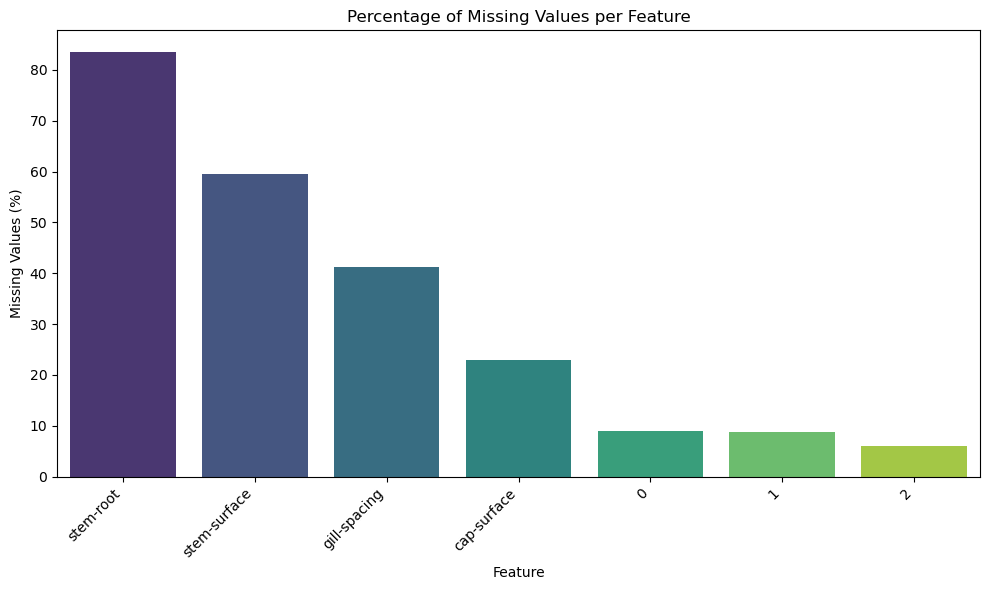

In [16]:
print()
print("=== Missing values ===")
miss = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%":     (df.isna().sum() / len(df) * 100).round(1)
})
print(miss[miss.missing_count > 0].sort_values("missing_%", ascending=False).to_string())
print(f"\nRows with ≥1 NaN: {df.isna().any(axis=1).sum()} / {len(df)} ({df.isna().any(axis=1).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=miss[miss["missing_count"] > 0].sort_values("missing_%", ascending=False).index,
    y=miss[miss["missing_count"] > 0].sort_values("missing_%", ascending=False)["missing_%"],
    palette="viridis",
    ax=ax
)

ax.set_title("Percentage of Missing Values per Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Anonymised and Corrupted Columns - Data Forensics

### Decoding categorical codes

We cross-referenced single-letter values against the public UCI *Secondary Mushroom Dataset* and documented every mapping, including unconfirmed ones:

- `cap-surface`: s=smooth, t=sticky, w=wrinkled, e=fleshy, i=fibrous, g=grooves, k=silky, l=leathery, y=scaly, h=shiny, **d=unmapped (hypothesis: "dry")**
- `gill-spacing`: c=close, d=distant, f=none
- `stem-root`: s=swollen, b=bulbous, r=rooted, c=club, **f=unmapped (assumed "none")**
- `stem-surface`: i=fibrous, y=scaly, f=none, s=smooth, h=shiny, g=grooves, k=silky, t=sticky
- `season`: w=winter, s=spring, u=summer, a=autumn
- `class`: 0=edible, 1=poisonous

### The numeric columns were deliberately tampered with

| Column | Decoded name | Corruption detected |
|---|---|---|
| `0` | cap-diameter (cm) | Injected giant outliers (max ≈ 18,342 cm - biologically impossible) |
| `1` | stem-height (cm) | Shifted into negatives by a constant offset (~10–12) |
| `2` | stem-width | Log-transformed and shifted by an unknown constant (all values ≈ −8.8, std ≈ 0.09). It *rises* with cap-diameter (Spearman ρ ≈ +0.7), so it was **not** negated |

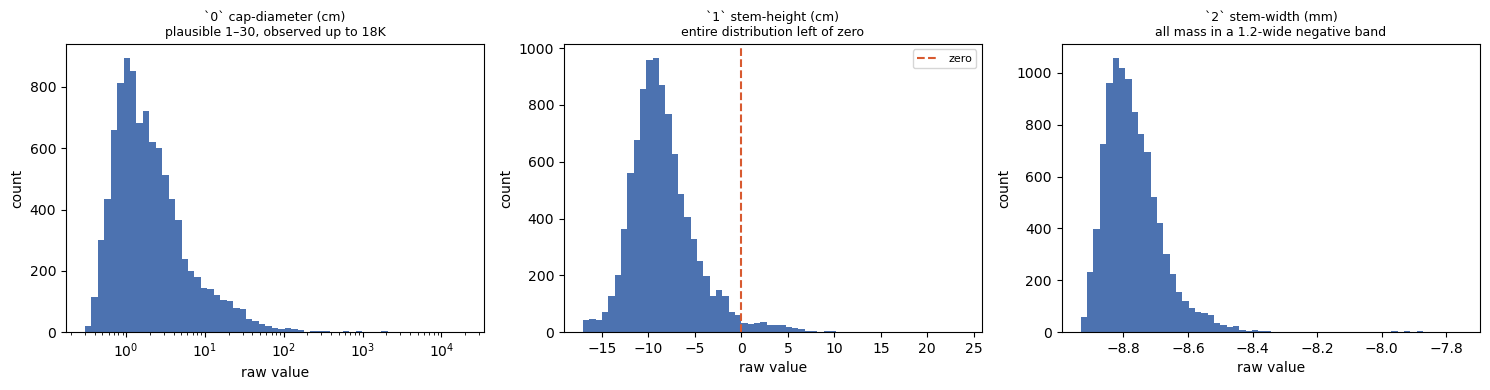

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["0"].dropna(),
             bins=np.logspace(np.log10(0.3), np.log10(20000), 60), color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_title("`0` cap-diameter (cm)\nplausible 1–30, observed up to 18K", fontsize=9)

axes[1].hist(df["1"].dropna(), bins=60, color="#4C72B0")
axes[1].axvline(0, color="#D85A30", ls="--", lw=1.5, label="zero")
axes[1].legend(fontsize=8)
axes[1].set_title("`1` stem-height (cm)\nentire distribution left of zero", fontsize=9)

axes[2].hist(df["2"].dropna(), bins=60, color="#4C72B0")
axes[2].set_title("`2` stem-width (mm)\nall mass in a 1.2-wide negative band", fontsize=9)

for ax in axes:
    ax.set_xlabel("raw value"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

In [18]:
print("=== Raw numeric statistics (corrupted columns) ===")
for col in ["0", "1", "2"]:
    s = df[col].dropna()
    print(f"  {col:15s}  min={s.min():10.2f}  max={s.max():10.2f}  "
          f"mean={s.mean():8.2f}  std={s.std():.4f}")

print()
print("Biologically plausible ranges:")
print("  cap-diameter : 1–30 cm   -> max 18,342 exposes injected outliers")
print("  stem-height  : 2–20 cm   -> all negative exposes constant offset")
print("  stem-width   : 3–30 mm   -> all negative, std=0.09 exposes log-transform + shift")

=== Raw numeric statistics (corrupted columns) ===
  0                min=      0.34  max=  18342.95  mean=   13.98  std=279.1828
  1                min=    -17.06  max=     23.85  mean=   -8.39  std=3.6480
  2                min=     -8.93  max=     -7.75  mean=   -8.77  std=0.0945

Biologically plausible ranges:
  cap-diameter : 1–30 cm   -> max 18,342 exposes injected outliers
  stem-height  : 2–20 cm   -> all negative exposes constant offset
  stem-width   : 3–30 mm   -> all negative, std=0.09 exposes log-transform + shift


## Data Cleaning and Feature Engineering

### Deterministic repairs
- `cap-diameter`: clipped at the 99th percentile, then log-transformed.
- `stem-height`: shifted by the training-fold minimum to remove the artificial negative offset.
- `stem-width`: `exp(x − median)` undoes the log-transform. The additive constant cannot be recovered, so width is expressed relative to the training-fold median (1 = typical stem). An earlier version used `exp(−x)`, which assumed a negation that the data contradicts: it made stem-width fall as caps grew (ρ = −0.75).

### Engineered features
- `height-width`, `cap-height`, `cap-width` are all ratios between the repaired dimensions.

The three fitted values (clip threshold, stem-height minimum, stem-width median) are learned inside the pipeline on the training fold only. No data leakage. No test-set information infiltration.

## The aftermath of feature engineering



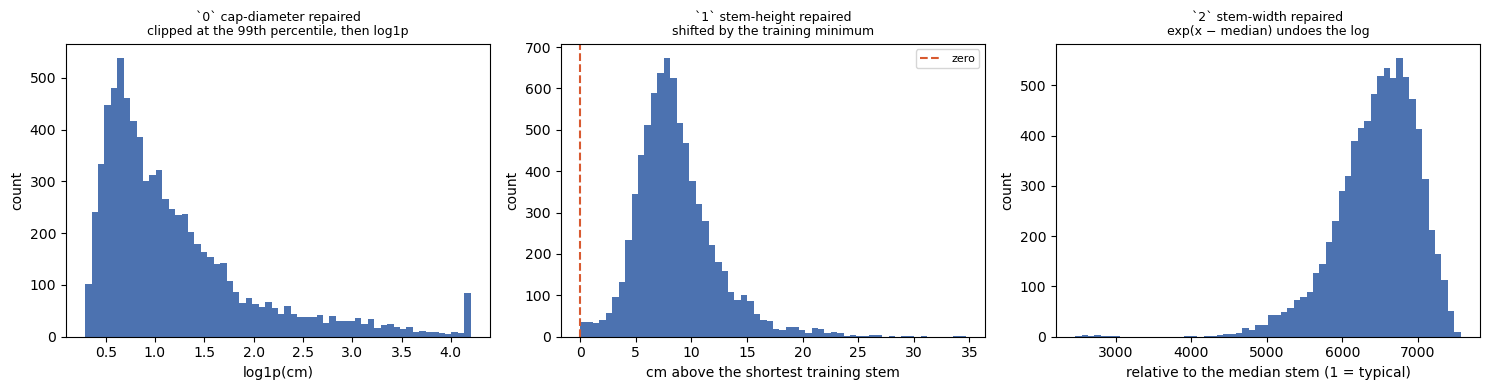

In [19]:
import matplotlib.pyplot as plt
from preprocessing import MushroomRepair, load_split

X_train, _, y_train, _ = load_split()
after = MushroomRepair().fit_transform(X_train)

BLUE, RED = "#4C72B0", "#D85A30"
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(after["0"].dropna(), bins=60, color=BLUE)
axes[0].set_title("`0` cap-diameter repaired\nclipped at the 99th percentile, then log1p", fontsize=9)
axes[0].set_xlabel("log1p(cm)")

axes[1].hist(after["1"].dropna(), bins=60, color=BLUE)
axes[1].axvline(0, color=RED, ls="--", lw=1.5, label="zero")
axes[1].legend(fontsize=8)
axes[1].set_title("`1` stem-height repaired\nshifted by the training minimum", fontsize=9)
axes[1].set_xlabel("cm above the shortest training stem")

axes[2].hist(after["2"].dropna(), bins=60, color=BLUE)
axes[2].set_title("`2` stem-width repaired\nexp(x − median) undoes the log", fontsize=9)
axes[2].set_xlabel("relative to the median stem (1 = typical)")

for ax in axes:
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

Refer to [preprocessing.py](./preprocessing.py) to see the full implementation.

## Redundancy Check - Correlation of the Repaired Features

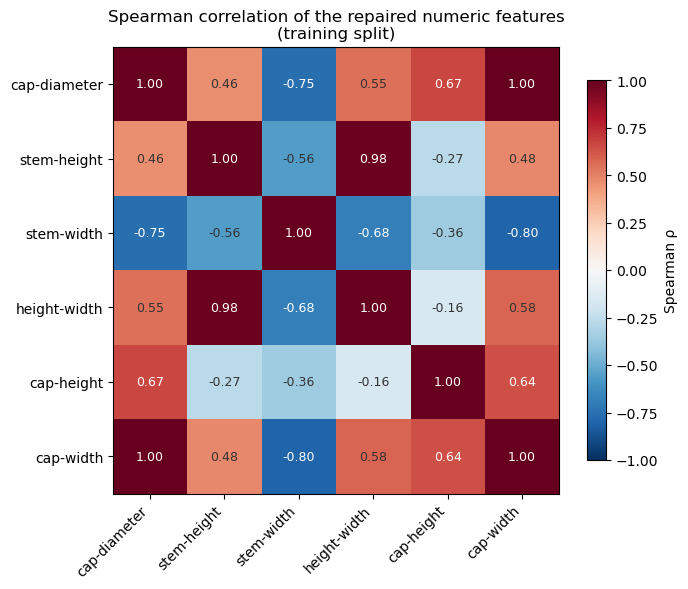

In [20]:
from matplotlib.ticker import PercentFormatter
from preprocessing import decode, CATEGORICAL_ALL, NUM_REPAIRED

GREEN, RED, BLUE, GREY, INK = "#1D9E75", "#D85A30", "#4C72B0", "#9A9A9A", "#333333"

labels = {"0": "cap-diameter", "1": "stem-height", "2": "stem-width",
          "height-width": "height-width", "cap-height": "cap-height", "cap-width": "cap-width"}
corr = after[NUM_REPAIRED].corr(method="spearman").rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else INK)
ax.set_title("Spearman correlation of the repaired numeric features\n(training split)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
plt.tight_layout(); plt.show()

- **The stem-width fix checks out:** repaired stem-width now rises with cap-diameter (ρ = +0.75) and stem-height (ρ = +0.56), as it should physically.
- **Two of the three ratios are near-copies of their numerators.** `cap-width` vs cap-diameter: ρ = 0.99; `height-width` vs stem-height: ρ = 0.97. Stem-width varies so little (IQR ≈ 0.95–1.06 × median) that dividing by it barely reorders anything.
- `cap-height` is the only ratio carrying information the raw dimensions don't already provide (ρ = −0.27 with stem-height).

Tree models are indifferent to such duplicates, but for the logistic regression they add collinearity without adding signal.

### Is missingness informative?

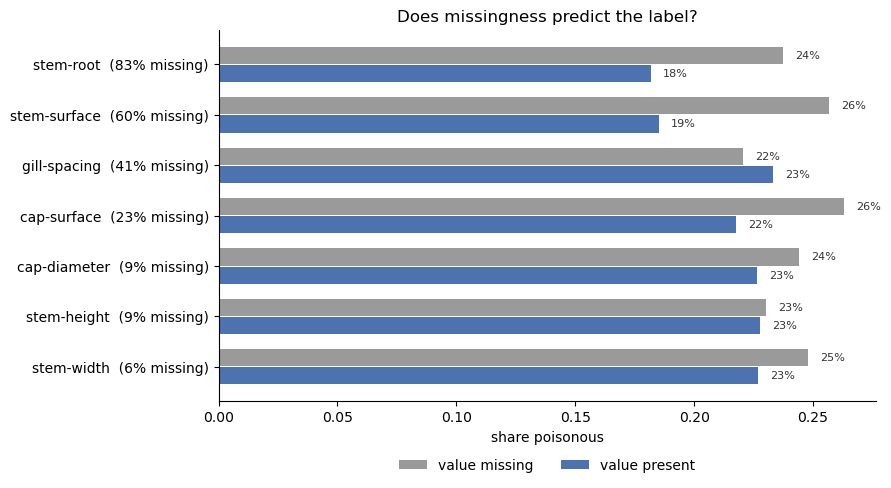

In [24]:
cols = [c for c in X_train.columns if X_train[c].isna().any()]
rows = []
for c in cols:
    m = X_train[c].isna()
    rows.append((labels.get(c, c), y_train[m].mean(), y_train[~m].mean(), m.mean()))
miss_rate = pd.DataFrame(rows, columns=["feature", "missing", "present", "share"]).set_index("feature")
miss_rate = miss_rate.sort_values("share")

fig, ax = plt.subplots(figsize=(9, 5))
ypos = np.arange(len(miss_rate))
ax.barh(ypos + 0.18, miss_rate.missing, height=0.34, color=GREY, label="value missing")
ax.barh(ypos - 0.18, miss_rate.present, height=0.34, color=BLUE, label="value present")
for y, (a, b) in enumerate(zip(miss_rate.missing, miss_rate.present)):
    ax.text(a + 0.005, y + 0.18, f"{a:.0%}", va="center", fontsize=8, color=INK)
    ax.text(b + 0.005, y - 0.18, f"{b:.0%}", va="center", fontsize=8, color=INK)
ax.set_yticks(ypos, [f"{f}  ({s:.0%} missing)" for f, s in zip(miss_rate.index, miss_rate.share)])
ax.set_xlabel("share poisonous")
ax.set_title("Does missingness predict the label?")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

- For the **numeric** columns and `gill-spacing`, the poisonous rate is the same whether the value is missing or not. Missingness looks random there.
- For **`stem-surface`, `stem-root`** and to a lesser degree `cap-surface` with a missing value are more often poisonous (24–26% vs 18–22%).This **justifies encoding it as its own `"missing"` category** rather than imputing the most frequent value.

Next: [Chapter 2: Modelling](./02_modelling.ipynb)